In [19]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import copy
import math

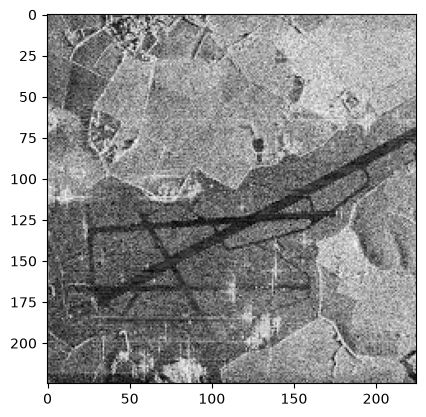

In [20]:
image = cv2.imread('sar_3.jpg')
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap='gray')

Task-1

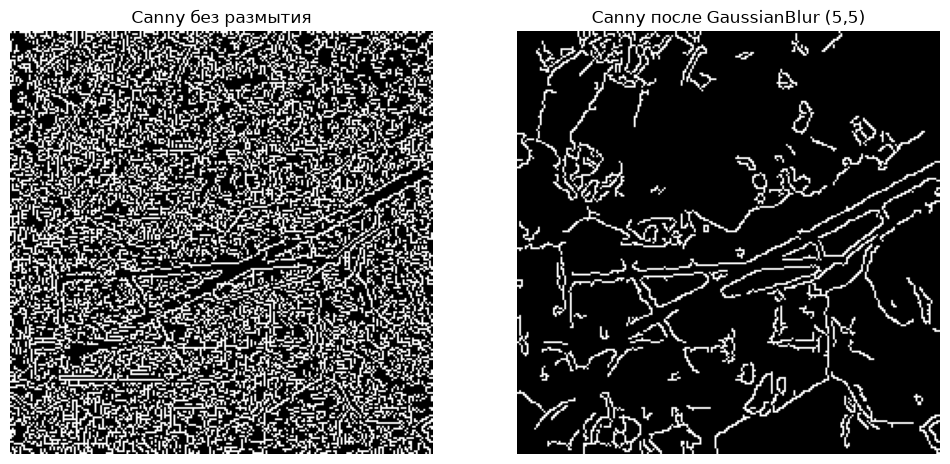

In [21]:
#Canny
image_blur = cv2.GaussianBlur(image_gray, (5,5), 0)
canny_noblur = cv2.Canny(image_gray, 100, 200)
canny = cv2.Canny(image_blur, 100, 200)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].set_title('Canny без размытия')
ax[0].imshow(canny_noblur, cmap='gray')
ax[1].set_title('Canny после GaussianBlur (5,5)')
ax[1].imshow(canny, cmap='gray')
for x in ax:
    x.axis('off')
plt.show()

найдено линий: 18


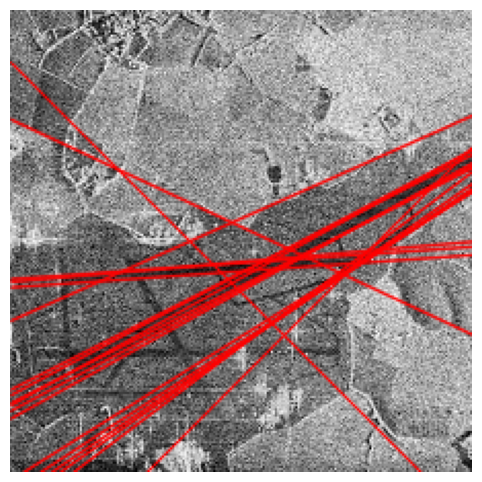

In [22]:
#HoughLines
lines = cv2.HoughLines(canny, 1, np.pi / 180, 60)
print('найдено линий:', len(lines))

image_lines = copy.deepcopy(image)
if lines is not None:
        for i in range(0, len(lines)):
            rho = lines[i][0][0]
            theta = lines[i][0][1]
            a = math.cos(theta)
            b = math.sin(theta)
            x0 = a * rho
            y0 = b * rho
            pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
            pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
            cv2.line(image_lines, pt1, pt2, (255,0,0), 1, cv2.LINE_AA)

plt.figure(figsize=(6, 6))
plt.imshow(image_lines)
plt.axis('off')
plt.show()

In [ ]:
lines_p = cv2.HoughLinesP(canny, 1, np.pi / 180, 50, minLineLength=30, maxLineGap=30)
lines_p = lines_p.reshape(-1, 4)

lengths = []
for x1, y1, x2, y2 in lines_p:
    lengths.append(math.sqrt((x2 - x1)**2 + (y2 - y1)**2))

best = lengths.index(max(lengths))
x1, y1, x2, y2 = [int(v) for v in lines_p[best]]
print('отрезков:', len(lines_p))
print('самый длинный:', (x1, y1), '->', (x2, y2), 'длина =', round(max(lengths), 1), 'пикс.')

image_segments = copy.deepcopy(image)
for s in lines_p:
    cv2.line(image_segments, (int(s[0]), int(s[1])), (int(s[2]), int(s[3])), (0,255,0), 1)
cv2.line(image_segments, (int(x1), int(y1)), (int(x2), int(y2)), (255,0,0), 2)

plt.figure(figsize=(6, 6))
plt.title('зеленые - все отрезки, красный - самый длинный')
plt.imshow(image_segments)
plt.axis('off')
plt.show()

Task-2

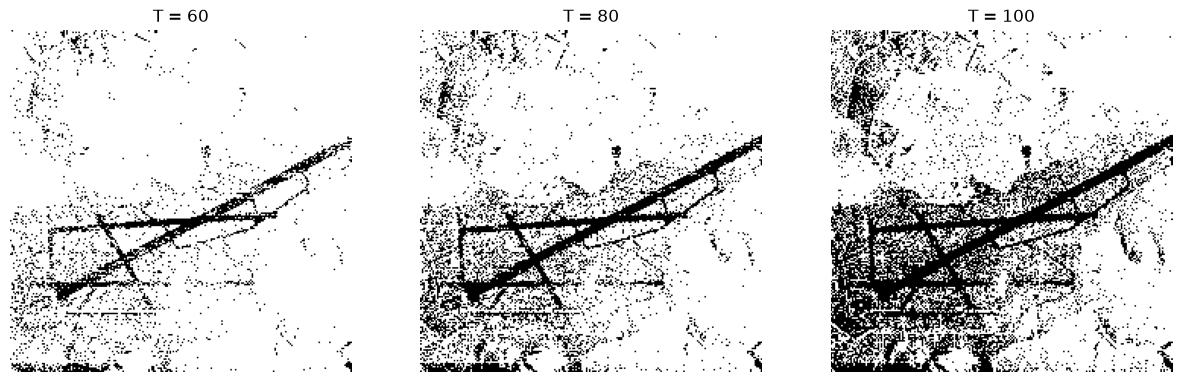

In [24]:
#Точечная бинаризация T = 60, 80, 100
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i, T in enumerate([60, 80, 100]):
    bin_img = copy.deepcopy(image_gray)
    bin_img[image_gray < T] = 0
    bin_img[image_gray >= T] = 255
    ax[i].set_title('T = ' + str(T))
    ax[i].imshow(bin_img, cmap='gray')
    ax[i].axis('off')
plt.show()

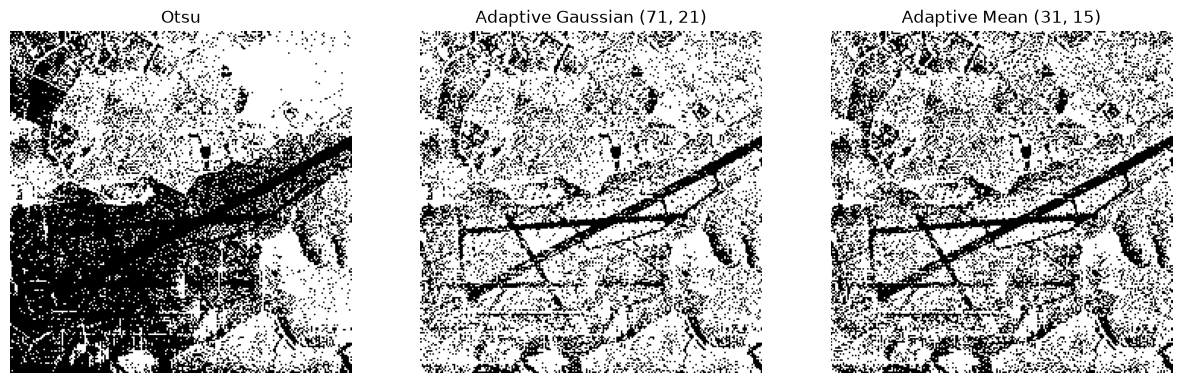

In [25]:
#Отсу и адаптивная
_,th2 = cv2.threshold(image_gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
th3 = cv2.adaptiveThreshold(image_gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv2.THRESH_BINARY,71,21)
th4 = cv2.adaptiveThreshold(image_gray,255,cv2.ADAPTIVE_THRESH_MEAN_C,\
            cv2.THRESH_BINARY,31,15)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].set_title('Otsu')
ax[0].imshow(th2, cmap='gray')
ax[1].set_title('Adaptive Gaussian (71, 21)')
ax[1].imshow(th3, cmap='gray')
ax[2].set_title('Adaptive Mean (31, 15)')
ax[2].imshow(th4, cmap='gray')
for x in ax:
    x.axis('off')
plt.show()

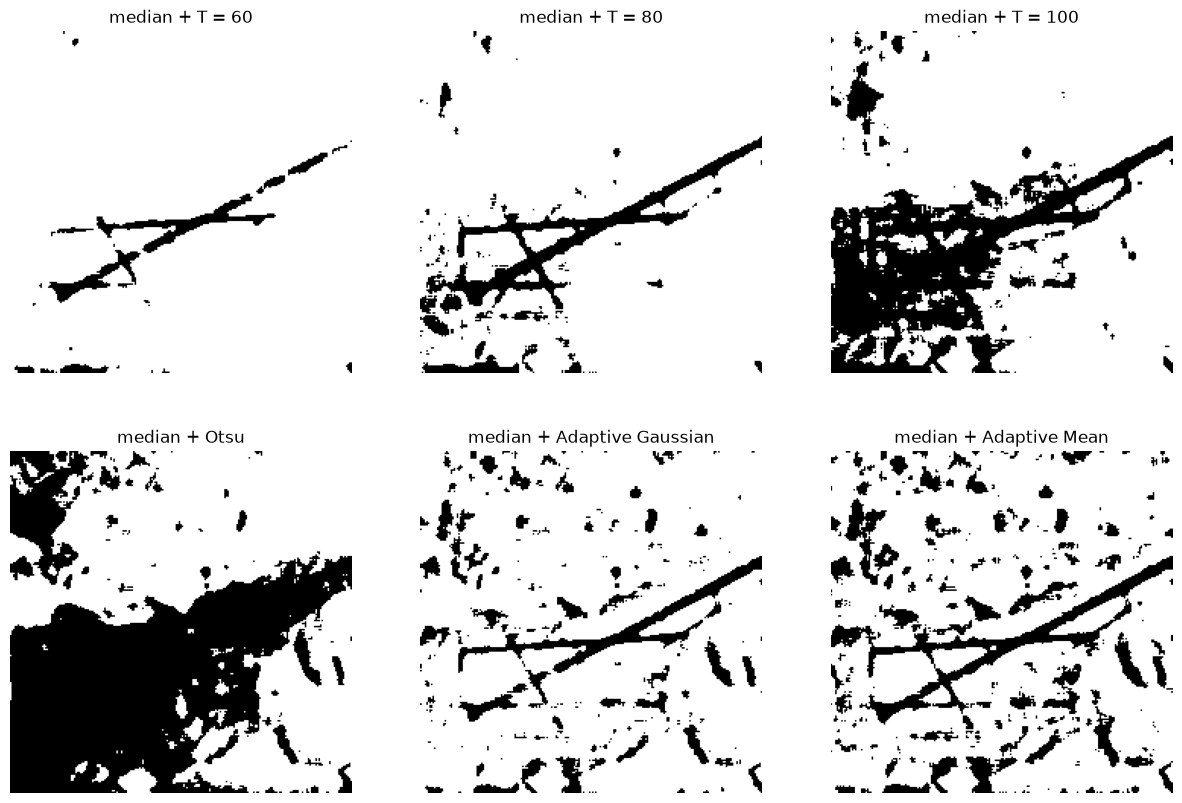

порог Отсу: 128.0


In [26]:
image_median = cv2.medianBlur(image_gray, 5)

results = []
names = []
for T in [60, 80, 100]:
    bin_img = copy.deepcopy(image_median)
    bin_img[image_median < T] = 0
    bin_img[image_median >= T] = 255
    results.append(bin_img)
    names.append('median + T = ' + str(T))

_,th2_m = cv2.threshold(image_median,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
th3_m = cv2.adaptiveThreshold(image_median,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv2.THRESH_BINARY,71,21)
th4_m = cv2.adaptiveThreshold(image_median,255,cv2.ADAPTIVE_THRESH_MEAN_C,\
            cv2.THRESH_BINARY,31,15)
results += [th2_m, th3_m, th4_m]
names += ['median + Otsu', 'median + Adaptive Gaussian', 'median + Adaptive Mean']

fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax = ax.flatten()
for i in range(len(results)):
    ax[i].set_title(names[i])
    ax[i].imshow(results[i], cmap='gray')
    ax[i].axis('off')
plt.show()

print('порог Отсу:', cv2.threshold(image_median,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)[0])

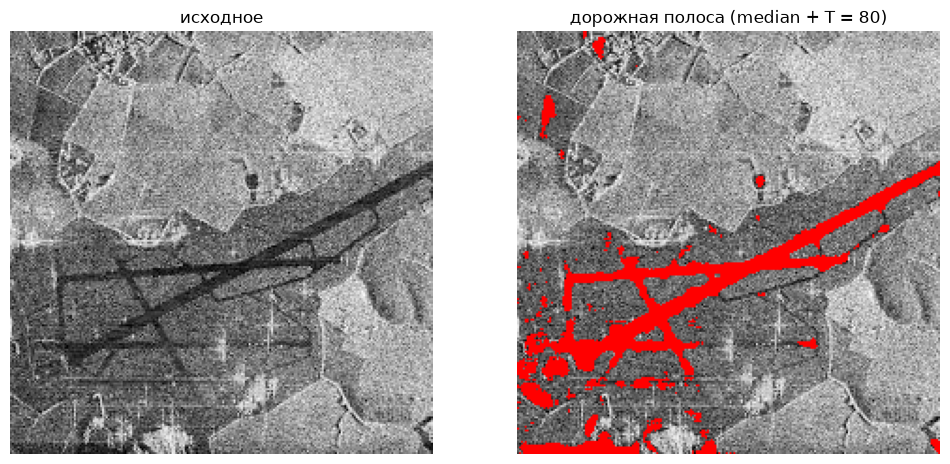

In [27]:
#выделение дорожной полосы
T = 80
mask = image_median < T

image_road = copy.deepcopy(image)
image_road[mask] = (255, 0, 0)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].set_title('исходное')
ax[0].imshow(image)
ax[1].set_title('дорожная полоса (median + T = 80)')
ax[1].imshow(image_road)
for x in ax:
    x.axis('off')
plt.show()

Вывод

- **Task-1.** Без размытия Canny на шумном радарном снимке находит тысячи мелких границ, и Хаф выдаёт тысячи ложных линий. После GaussianBlur (5,5) остаются в основном границы полос. HoughLines находит 18 прямых, большинство идёт вдоль главной диагональной полосы. Из-за спекл-шума край полосы после Canny получается прерывистым, поэтому в HoughLinesP нужен maxLineGap = 30: при maxLineGap = 10 полоса распадается на куски, и самый длинный из них покрывает только половину полосы (~115 пикс.). С maxLineGap = 30 самый протяжённый отрезок идёт вдоль всей главной взлётной полосы, его длина около 246 пикселей (красный отрезок).
- **Task-2.** Отсу здесь работает плохо: гистограмма не делится на два чётких пика, порог получается 128, и в чёрное уходит половина снимка. Адаптивная бинаризация выделяет полосы, но вместе с ними много тёмных пятен полей. Точечная бинаризация без фильтра даёт сильную зернистость из-за спекл-шума.
- Лучший результат даёт **медианный фильтр 5 + точечная бинаризация с T = 80**: полосы получаются сплошными, а лишнего почти нет. При T = 60 полосы рвутся, при T = 100 к ним прилипают тёмные поля.